In [1]:
from pathlib import Path
import pandas as pd
from sklearn.model_selection import train_test_split

data_dir = Path('data')
enron_file = data_dir / 'enron_spam_data.zip'

raw_data = pd.read_csv(enron_file, compression='zip')
df = pd.DataFrame({
    'text': raw_data['Subject'].fillna('') + ' ' + raw_data['Message'].fillna(''),
    'label': (raw_data['Spam/Ham'] == 'spam').astype(int)
})

df['text'] = df['text'].str.strip()
df = df[df['text'].str.len() > 0].drop_duplicates(subset='text')

X_train, X_test, y_train, y_test = train_test_split(
    df['text'].values,
    df['label'].values,
    test_size=0.2,
    stratify=df['label'],
    random_state=42
)

print(f"Data ready. Train: {len(X_train)}, Test: {len(X_test)}")

Data ready. Train: 24369, Test: 6093


In [2]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline

base_model = MultinomialNB(alpha=1.0)
calibrated_nb = CalibratedClassifierCV(estimator=base_model, method='sigmoid', cv=5)

model_calibrated = Pipeline([
    ('vect', CountVectorizer(stop_words='english', min_df=3, max_df=0.9)),
    ('clf', calibrated_nb)
])

print("Training calibrated model...")
model_calibrated.fit(X_train, y_train)
print("Training completed.")

Training calibrated model...
Training completed.


In [3]:
from sklearn.metrics import classification_report

print("Evaluating...")
y_pred = model_calibrated.predict(X_test)

print("\n" + "=" * 55)
print("Classification Report (Exercise 3: Probability Calibration)")
print("=" * 55)
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam'], digits=4))

Evaluating...

Classification Report (Exercise 3: Probability Calibration)
              precision    recall  f1-score   support

         Ham     0.9893    0.9840    0.9866      3182
        Spam     0.9826    0.9883    0.9854      2911

    accuracy                         0.9860      6093
   macro avg     0.9859    0.9861    0.9860      6093
weighted avg     0.9861    0.9860    0.9861      6093



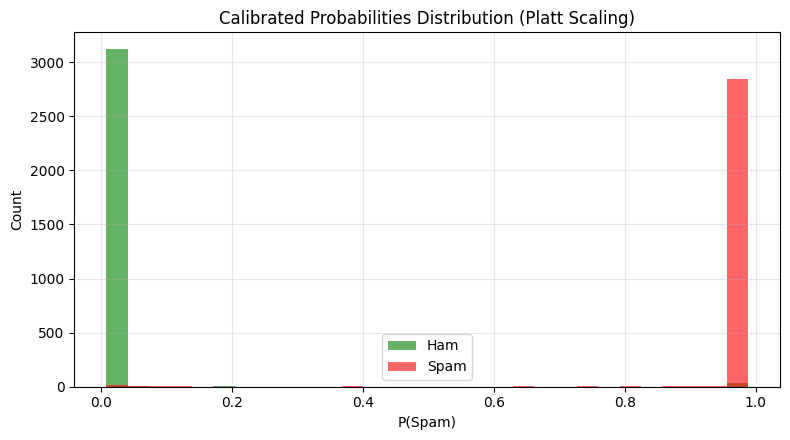

In [4]:
import matplotlib.pyplot as plt

probs = model_calibrated.predict_proba(X_test)[:, 1]

plt.figure(figsize=(8, 4.5))
plt.hist(probs[y_test == 0], bins=30, alpha=0.6, color='green', label='Ham')
plt.hist(probs[y_test == 1], bins=30, alpha=0.6, color='red', label='Spam')
plt.title("Calibrated Probabilities Distribution (Platt Scaling)")
plt.xlabel("P(Spam)")
plt.ylabel("Count")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()